# Clustering Parameter Optimisation — Diagnostics Report

This notebook analyses the results of a grid-search over embedding, UMAP,
and HDBSCAN parameters for text clustering.  It is designed to be
**dataset-agnostic**: change the single `OUTPUT_DIR` variable below and
re-run all cells to produce a full report for any new dataset.

### Report sections

| # | Section | Purpose |
|---|---------|--------|
| 1 | **Configuration & data loading** | One place to point at a new dataset |
| 2 | **Overview table** | Quick glance at every configuration |
| 3 | **Metric correlations** | Which parameters drive which metrics? |
| 4 | **Pairwise metric scatter** | Trade-offs between key metrics |
| 5 | **Marginal effects** | Individual parameter influence on silhouette |
| 6 | **Parameter interactions** | HDBSCAN parameter heatmaps |
| 7 | **Cluster quality trade-offs** | n_clusters vs silhouette bubble chart |
| 8 | **Best configurations** | Top-k configs & parameter ranges |
| 9 | **Summary** | Key take-aways |

---
## 1 · Configuration

Edit the cell below to point at a different dataset. Everything else
adapts automatically.

In [41]:
from pathlib import Path

BASE_DIR   = Path("/m/cs/scratch/ecanet/blsky-trump/output/")
DATASET    = "dataset_d"          # change this for another dataset
OUTPUT_DIR = BASE_DIR / DATASET / "clusters"

TOP_K      = 9                    # number of configs shown in the ranking table

PARAM_COLS = [
    "embedding_dims",
    "umap_components",
    "umap_neighbors",
    "umap_min_dist",
    "min_cluster_size",
    "min_samples",
    "cluster_selection_epsilon",
]

METRIC_COLS  = ["n_clusters", "noise_pct", "silhouette", "trustworthiness", "avg_prob"]
KEY_METRICS  = ["n_clusters", "noise_pct", "silhouette"]

In [42]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
from matplotlib import cm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

---
## 2 · Data loading & overview

In [43]:
json_paths = sorted(OUTPUT_DIR.glob("*.json"))
if not json_paths:
    raise FileNotFoundError(f"No JSON files found in: {OUTPUT_DIR}")

rows = []
for path in json_paths:
    with path.open("r", encoding="utf-8") as f:
        rows.append(json.load(f))

df_configs = pd.DataFrame(rows)
if "config_id" in df_configs.columns:
    df_configs = df_configs.sort_values("config_id").reset_index(drop=True)

print(f"Loaded {len(df_configs)} configs from {OUTPUT_DIR}")
df_configs.sort_values("silhouette", ascending=False)

Loaded 15 configs from /m/cs/scratch/ecanet/blsky-trump/output/dataset_d/clusters


,config_id,embedding_dims,umap_components,umap_neighbors,umap_min_dist,min_cluster_size,min_samples,cluster_selection_epsilon,n_clusters,n_noise,noise_pct,silhouette,trustworthiness,avg_prob
3,5,256,15,20,0.05,500,50,0.00,1111,4592906,60.8770,0.5270,0.9509,0.8111
10,15,128,10,20,0.05,300,50,0.00,1431,4918860,65.1974,0.5193,0.9479,0.7994
6,8,128,15,15,0.05,300,25,0.00,1538,4962132,65.7710,0.5168,0.9465,0.7972
8,13,256,15,20,0.05,300,50,0.00,1618,4582868,60.7440,0.5049,0.9509,0.8076
12,17,256,15,15,0.10,300,100,0.00,1445,4803943,63.6742,0.4867,0.9506,0.8136
13,18,128,10,20,0.10,400,50,0.00,1073,5083627,67.3813,0.4768,0.9494,0.8120
0,2,128,10,10,0.10,300,100,0.05,1239,5012697,66.4412,0.4610,0.9428,0.8202
11,16,256,15,15,0.10,500,50,0.05,1009,4725731,62.6376,0.4551,0.9505,0.8248
14,19,128,10,20,0.05,500,100,0.05,877,4520271,59.9143,0.4514,0.9479,0.8296
2,4,128,15,10,0.10,500,50,0.00,876,5011392,66.4239,0.4482,0.9452,0.8301


---
## 3 · Metric correlations (Spearman)

Non-parametric rank correlation between every parameter and every metric.
Strong |ρ| between a parameter and `silhouette` flags the most influential
knobs.

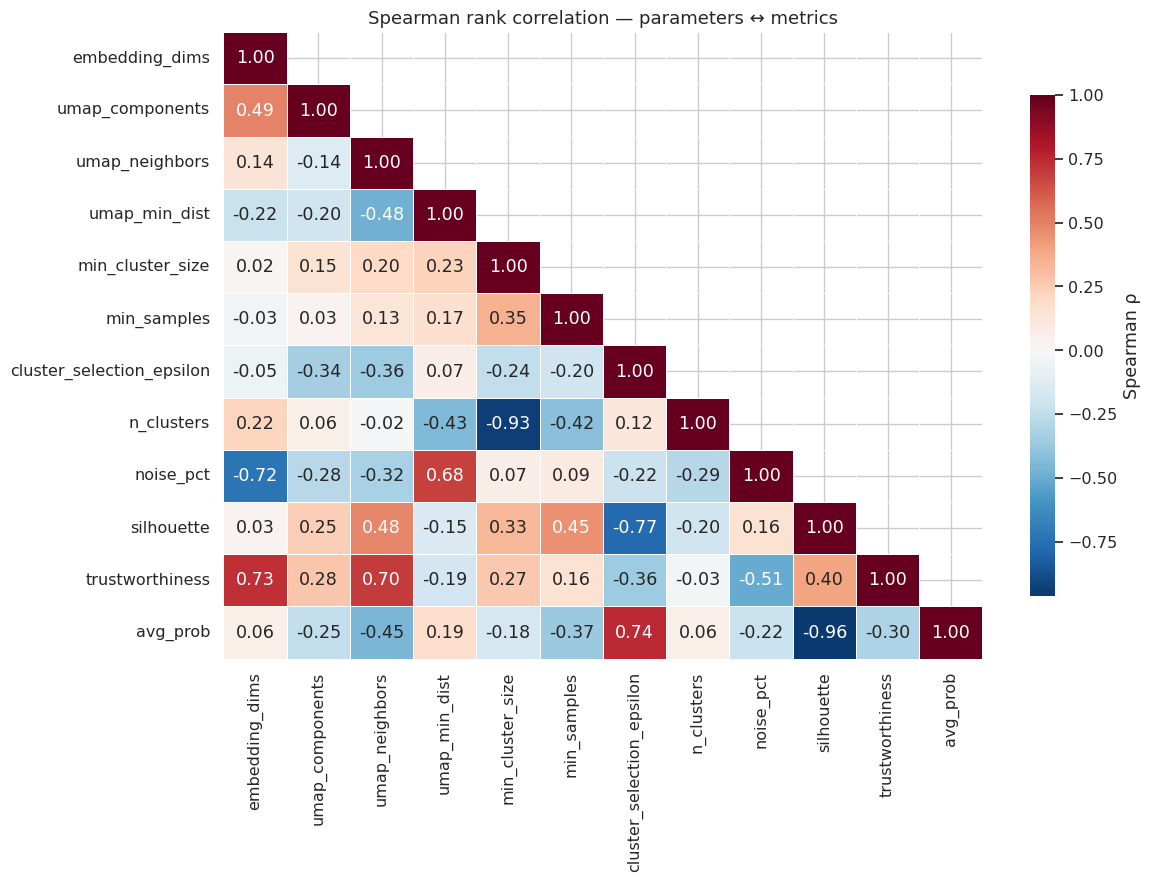

In [44]:
corr = df_configs[PARAM_COLS + METRIC_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Spearman ρ"},
)
ax.set_title("Spearman rank correlation — parameters ↔ metrics", fontsize=13)
plt.tight_layout()
plt.show()

---
## 4 · Pairwise scatter matrix of key metrics

Shows the trade-off surface between `n_clusters`, `noise_pct`, and
`silhouette`.  Configs that are Pareto-optimal sit on the upper-left of
`silhouette` vs `noise_pct`.

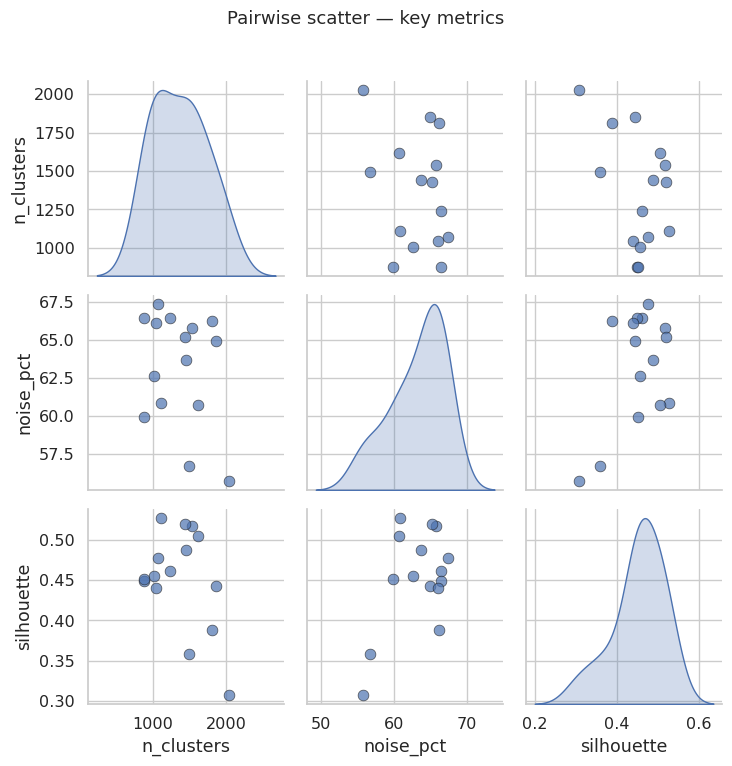

In [45]:
g = sns.pairplot(
    df_configs[KEY_METRICS],
    diag_kind="kde",
    plot_kws=dict(alpha=0.7, edgecolor="k", linewidth=0.5, s=60),
    diag_kws=dict(fill=True),
)
g.figure.suptitle("Pairwise scatter — key metrics", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## 5 · Marginal effects — each parameter vs silhouette

Strip-plot overlaid with per-level means.  Reveals which individual
parameter values tend to push silhouette up or down.

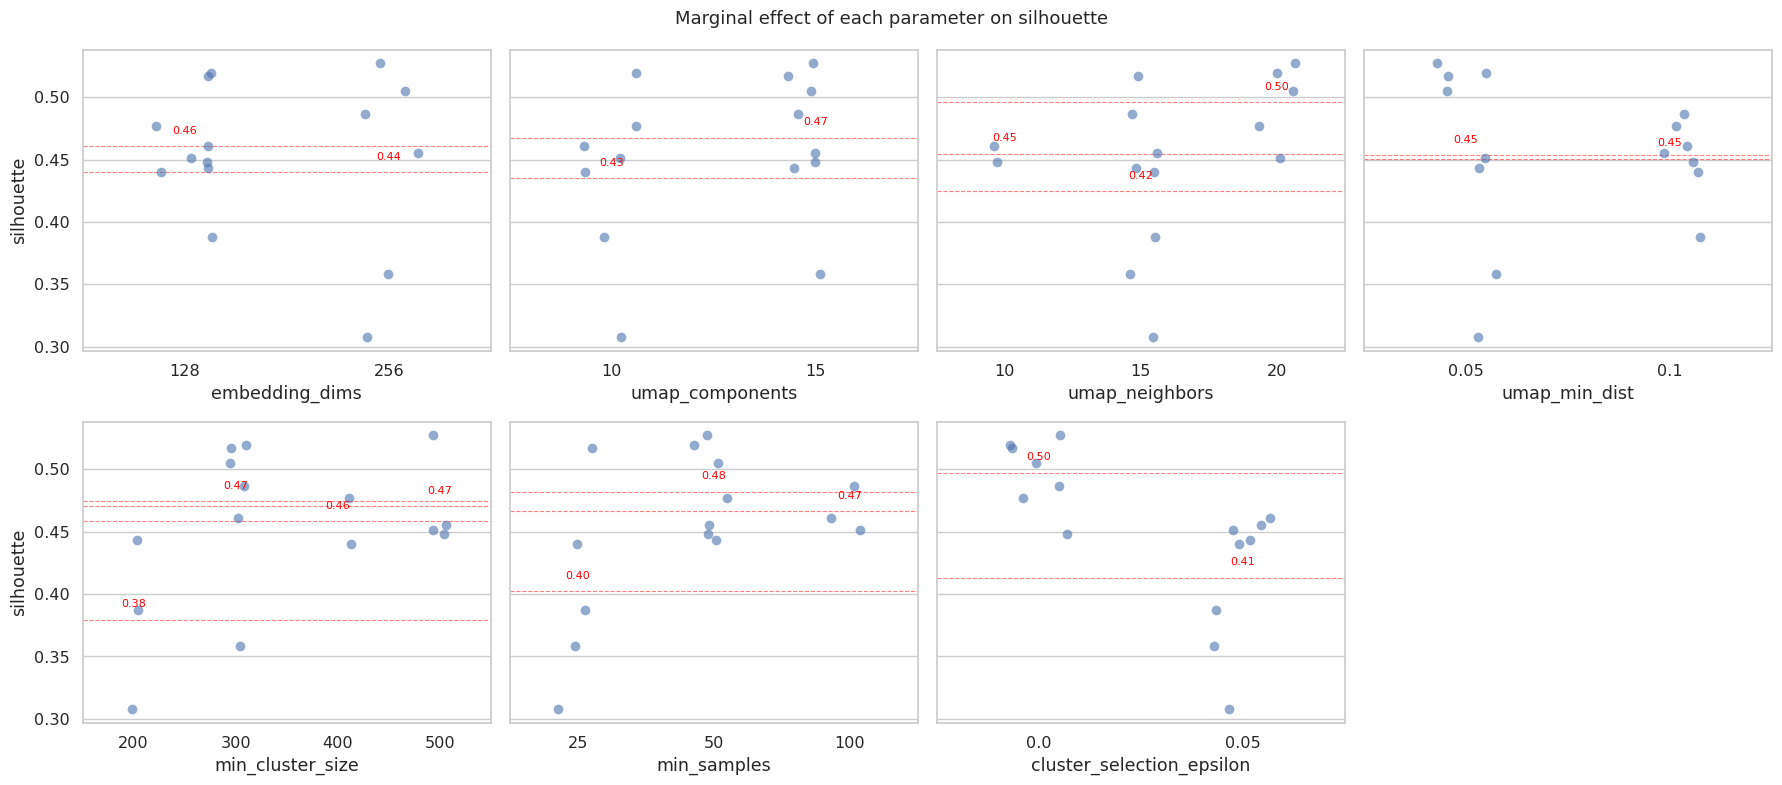

In [46]:
n_params = len(PARAM_COLS)
ncols = 4
nrows = (n_params + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=True)
axes = axes.ravel()

for i, col in enumerate(PARAM_COLS):
    ax = axes[i]
    sorted_vals = sorted(df_configs[col].unique())
    order = [str(v) for v in sorted_vals]
    vals = df_configs[col].astype(str)

    sns.stripplot(x=vals, y=df_configs["silhouette"], ax=ax, order=order,
                  jitter=0.15, alpha=0.6, size=7)

    means = df_configs.groupby(col)["silhouette"].mean()
    for x_idx, val in enumerate(sorted_vals):
        m = means[val]
        ax.axhline(m, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.text(x_idx, m + 0.01, f"{m:.2f}", ha="center", fontsize=8, color="red")

    ax.set_xlabel(col)
    if i == 0:
        ax.set_ylabel("silhouette")

for j in range(n_params, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Marginal effect of each parameter on silhouette", fontsize=13)
plt.tight_layout()
plt.show()

---
## 6 · Parameter interactions (HDBSCAN)

Average silhouette for every combination of `min_cluster_size ×
cluster_selection_epsilon`, `min_cluster_size × min_samples`, and
`min_samples × cluster_selection_epsilon`.  Darker green → better
silhouette.

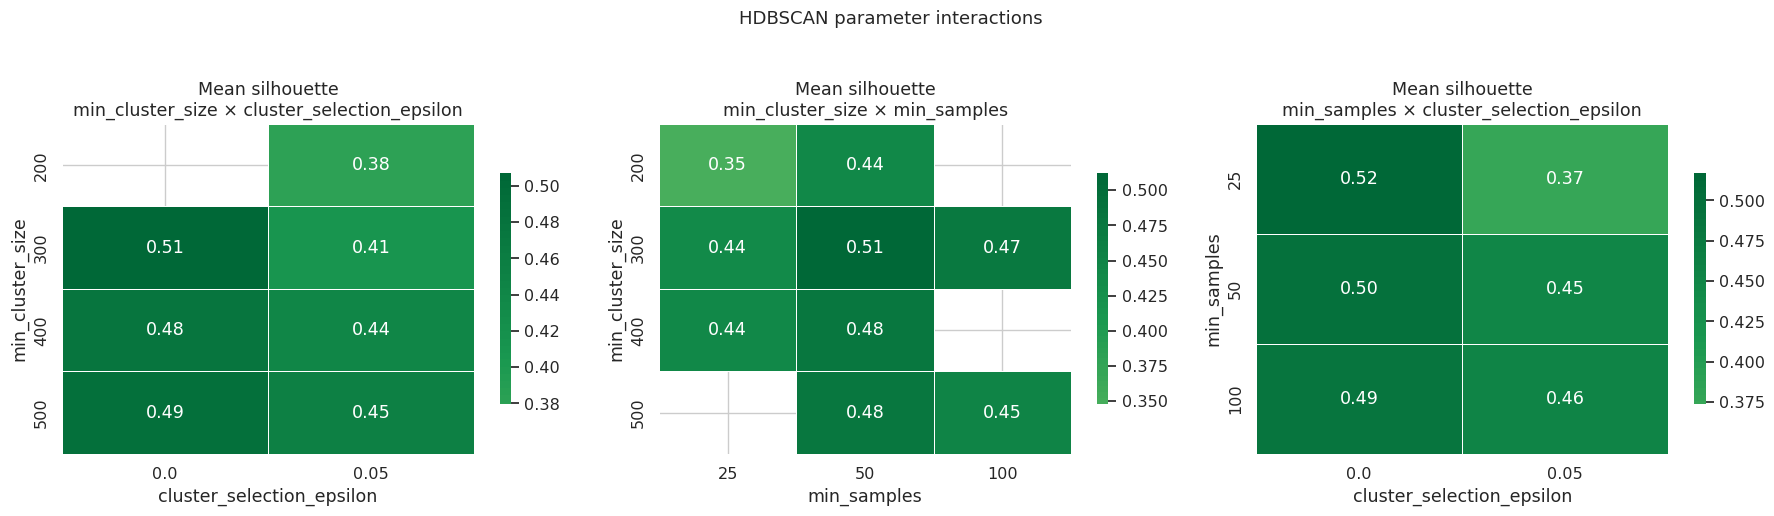

In [47]:
hdbscan_pairs = [
    ("min_cluster_size", "cluster_selection_epsilon"),
    ("min_cluster_size", "min_samples"),
    ("min_samples", "cluster_selection_epsilon"),
]

fig, axes = plt.subplots(1, len(hdbscan_pairs), figsize=(6 * len(hdbscan_pairs), 5))
if len(hdbscan_pairs) == 1:
    axes = [axes]
for ax, (p1, p2) in zip(axes, hdbscan_pairs):
    pivot = df_configs.pivot_table(
        index=p1, columns=p2, values="silhouette", aggfunc="mean"
    )
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax,
                linewidths=0.5, cbar_kws={"shrink": 0.7})
    ax.set_title(f"Mean silhouette\n{p1} × {p2}")

fig.suptitle("HDBSCAN parameter interactions", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

---
## 7 · Cluster quality trade-offs

Each point is a config.  Bubble size and colour encode `noise_pct`.

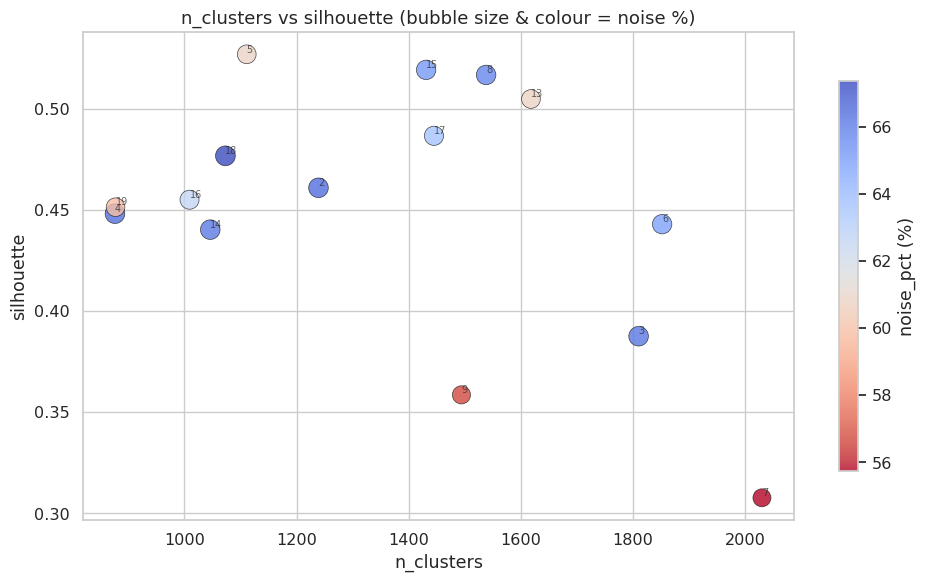

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    df_configs["n_clusters"],
    df_configs["silhouette"],
    c=df_configs["noise_pct"],
    s=df_configs["noise_pct"] * 3,
    cmap="coolwarm_r",
    edgecolors="k",
    linewidth=0.5,
    alpha=0.8,
)
for _, r in df_configs.iterrows():
    ax.annotate(
        int(r["config_id"]),
        (r["n_clusters"], r["silhouette"]),
        fontsize=7, ha="left", va="bottom", alpha=0.7,
    )

fig.colorbar(sc, ax=ax, label="noise_pct (%)", shrink=0.8)
ax.set_xlabel("n_clusters")
ax.set_ylabel("silhouette")
ax.set_title("n_clusters vs silhouette (bubble size & colour = noise %)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 8 · Best configurations

Sorted table of the top runs (ranked by silhouette), plus a quick
summary of the parameter ranges that appear in the best half of all
configs.

In [49]:
display_cols = ["config_id"] + PARAM_COLS + KEY_METRICS
top_k_df = df_configs.nlargest(TOP_K, "silhouette")[display_cols]
display(top_k_df.style.background_gradient(subset=["silhouette"], cmap="RdYlGn"))

median_sil = df_configs["silhouette"].median()
top_half = df_configs[df_configs["silhouette"] >= median_sil]

print("\n— Parameter ranges in top-half configs (silhouette ≥ median) —")
for col in PARAM_COLS:
    vals = sorted(top_half[col].unique())
    print(f"  {col:>30s}: {vals}")

,config_id,embedding_dims,umap_components,umap_neighbors,umap_min_dist,min_cluster_size,min_samples,cluster_selection_epsilon,n_clusters,noise_pct,silhouette
3,5,256,15,20,0.050000,500,50,0.000000,1111,60.877000,0.527000
10,15,128,10,20,0.050000,300,50,0.000000,1431,65.197400,0.519300
6,8,128,15,15,0.050000,300,25,0.000000,1538,65.771000,0.516800
8,13,256,15,20,0.050000,300,50,0.000000,1618,60.744000,0.504900
12,17,256,15,15,0.100000,300,100,0.000000,1445,63.674200,0.486700
13,18,128,10,20,0.100000,400,50,0.000000,1073,67.381300,0.476800
0,2,128,10,10,0.100000,300,100,0.050000,1239,66.441200,0.461000
11,16,256,15,15,0.100000,500,50,0.050000,1009,62.637600,0.455100
14,19,128,10,20,0.050000,500,100,0.050000,877,59.914300,0.451400



— Parameter ranges in top-half configs (silhouette ≥ median) —
                  embedding_dims: [np.int64(128), np.int64(256)]
                 umap_components: [np.int64(10), np.int64(15)]
                  umap_neighbors: [np.int64(10), np.int64(15), np.int64(20)]
                   umap_min_dist: [np.float64(0.05), np.float64(0.1)]
                min_cluster_size: [np.int64(300), np.int64(400), np.int64(500)]
                     min_samples: [np.int64(25), np.int64(50), np.int64(100)]
       cluster_selection_epsilon: [np.float64(0.0), np.float64(0.05)]


---
## 9 · Summary

The cell below auto-generates a concise textual summary from the data.

In [50]:
best = df_configs.loc[df_configs["silhouette"].idxmax()]
worst = df_configs.loc[df_configs["silhouette"].idxmin()]

print(f"Dataset          : {DATASET}")
print(f"Configs evaluated: {len(df_configs)}")
print()
print(f"Best silhouette  : {best['silhouette']:.4f}  (config {int(best['config_id'])})")
print(f"Worst silhouette : {worst['silhouette']:.4f}  (config {int(worst['config_id'])})")
print(f"Median silhouette: {median_sil:.4f}")
print()
print("Best config parameters:")
for col in PARAM_COLS:
    print(f"  {col:>30s} = {best[col]}")
print()
print(f"  → n_clusters  = {int(best['n_clusters'])}")
print(f"  → noise_pct   = {best['noise_pct']:.2f} %")
print(f"  → silhouette  = {best['silhouette']:.4f}")

Dataset          : dataset_d
Configs evaluated: 15

Best silhouette  : 0.5270  (config 5)
Worst silhouette : 0.3077  (config 7)
Median silhouette: 0.4551

Best config parameters:
                  embedding_dims = 256.0
                 umap_components = 15.0
                  umap_neighbors = 20.0
                   umap_min_dist = 0.05
                min_cluster_size = 500.0
                     min_samples = 50.0
       cluster_selection_epsilon = 0.0

  → n_clusters  = 1111
  → noise_pct   = 60.88 %
  → silhouette  = 0.5270
